**Step 1: Import Libraries**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


**Step 2: Load and Preprocess MNIST Dataset**

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape data for CNN (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


**Step 3: Build the CNN Model**

In [3]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 digits (0–9)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Step 4: Compile the Model**

In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 **Step 5: Train the Model**

In [5]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step - accuracy: 0.8824 - loss: 0.3818 - val_accuracy: 0.9813 - val_loss: 0.0611
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 48ms/step - accuracy: 0.9833 - loss: 0.0524 - val_accuracy: 0.9885 - val_loss: 0.0414
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9884 - loss: 0.0361 - val_accuracy: 0.9897 - val_loss: 0.0355
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9921 - loss: 0.0237 - val_accuracy: 0.9898 - val_loss: 0.0410
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - accuracy: 0.9948 - loss: 0.0153 - val_accuracy: 0.9912 - val_loss: 0.0313



**Step 6: Evaluate the Model**


In [6]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9893 - loss: 0.0296
Test Accuracy: 0.9911999702453613


**# Step 7: Plot Training Accuracy & LOSS**

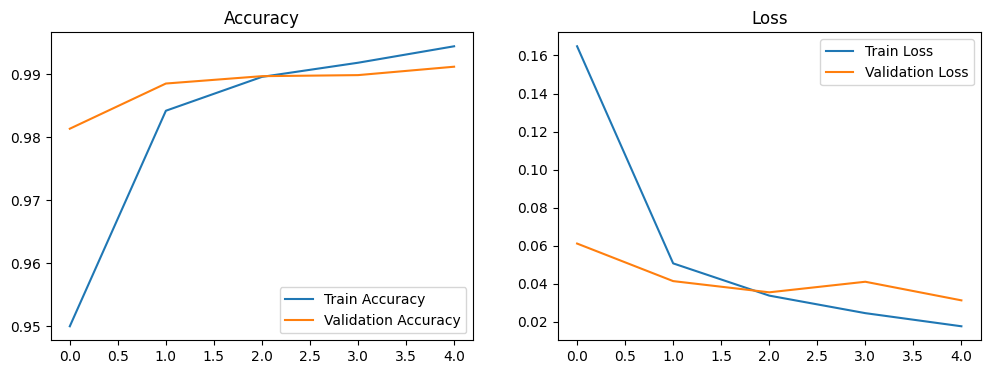

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()



**Step 8: Predict a Sample Digit**





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step


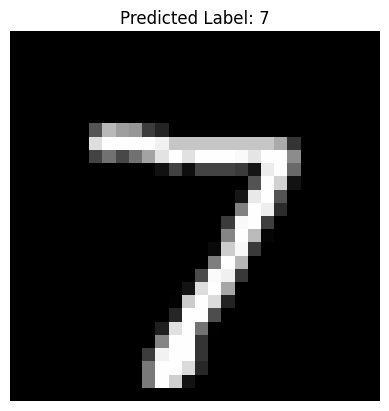

In [8]:
import numpy as np

index = 0
prediction = model.predict(x_test[index].reshape(1,28,28,1))
predicted_label = np.argmax(prediction)

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted Label: {predicted_label}")
plt.axis('off')
plt.show()


| Aspect                     | ANN (Artificial Neural Network)                                        | CNN (Convolutional Neural Network)                                 |
| -------------------------- | ---------------------------------------------------------------------- | ------------------------------------------------------------------ |
| **Input Representation**   | MNIST images are **flattened** into a 1D vector (28×28 = 784 features) | MNIST images are kept in **2D form (28×28×1)**                     |
| **Spatial Information**    | **Lost** due to flattening                                             | **Preserved** using convolution operations                         |
| **Feature Extraction**     | Features are **manually learned** through fully connected layers       | Features are **automatically extracted** using convolution filters |
| **Weight Sharing**         | Each neuron has **separate weights**                                   | Filters are **shared across the image**, reducing parameters       |
| **Number of Parameters**   | **High**, leading to overfitting                                       | **Lower**, more efficient                                          |
| **Translation Invariance** | Cannot handle shifted digits well                                      | Robust to **shifted and rotated digits**                           |
| **Architecture**           | Fully connected layers only                                            | Convolution + Pooling + Fully Connected layers                     |
| **Accuracy on MNIST**      | ~92–95%                                                                | ~98–99%                                                            |
| **Training Time**          | Faster for small models                                                | Slightly slower but more accurate                                  |
| **Suitability for MNIST**  | Acceptable for simple learning                                         | **Best choice for image classification**                           |


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


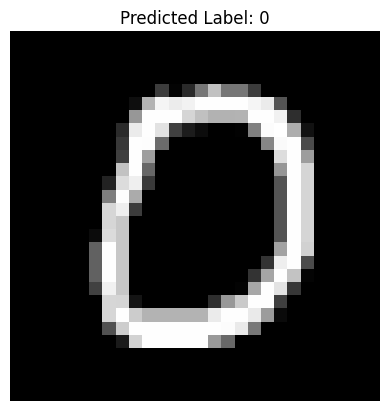

In [9]:
import numpy as np

index = 10
prediction = model.predict(x_test[index].reshape(1,28,28,1))
predicted_label = np.argmax(prediction)

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted Label: {predicted_label}")
plt.axis('off')
plt.show()
